In [1]:
from src.ColorsAnalysis import *
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from IPython.display import clear_output
plt.style.use('properties.mplstyle')

In [2]:
results_folder = "../results/ColorAnalysis"
create_folder(results_folder)

Folder already exists: ../results/ColorAnalysis


In [3]:
df_dynamic = pd.read_csv("../SOP_data/all_colors_dynamic.dat", sep=' ')
df_dynamic

,type_perc,dim,L,f_T,c,num_colors,P0,p0,N_samples,rho,nc,nc_err,nc_std,stat_window,stop_criterion,t_eq_validation,t_eq_s_prime_threshold,equilibrium_effective_rel_tol,post_equilibrium_extra_steps
0,bond,3,64,0.001000,0.001,1,0.2,0.6,1004,1.00000,0.992032,0.002807,0.088952,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
1,bond,3,64,0.014759,0.001,1,0.2,0.6,502,1.00000,0.994024,0.003443,0.077151,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
2,bond,3,64,0.028517,0.001,1,0.2,0.6,502,1.00000,1.000000,0.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
3,bond,3,64,0.001000,0.005,1,0.2,0.6,502,1.00000,0.131474,0.015097,0.338255,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
4,bond,3,64,0.014759,0.005,1,0.2,0.6,502,1.00000,0.575697,0.022081,0.494730,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2141,bond,3,512,0.379000,0.200,3,0.2,0.6,25,0.33333,3.000000,0.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
2142,bond,3,1024,0.379000,0.200,3,0.2,0.6,5,0.33333,3.000000,0.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
2143,bond,3,256,0.400000,0.200,3,0.2,0.6,150,0.33333,3.000000,0.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0
2144,bond,3,512,0.400000,0.200,3,0.2,0.6,25,0.33333,3.000000,0.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100.0


In [4]:
df_series = pd.read_csv('../SOP_data/all_data_dynamic.dat', sep=' ')
df_series

,type_perc,dim,L,f_T,c,nc,rho,p0,P0,order,...,z_max_mean,z_max_err,z_stat_mean,z_stat_err,stat_window,stop_criterion,t_eq_validation,t_eq_s_prime_threshold,equilibrium_effective_rel_tol,post_equilibrium_extra_steps
0,bond,3,64,0.001000,0.001,1,1.00000,0.6,0.2,0,...,452.640562,0.256744,436.367470,0.276080,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100
1,bond,3,64,0.014759,0.001,1,1.00000,0.6,0.2,0,...,463.703407,0.409916,445.416834,0.427283,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100
2,bond,3,64,0.028517,0.001,1,1.00000,0.6,0.2,0,...,472.657371,0.403438,452.336653,0.446670,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100
3,bond,3,64,0.001000,0.005,1,1.00000,0.6,0.2,0,...,121.484848,1.139714,111.954545,0.695450,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100
4,bond,3,64,0.014759,0.005,1,1.00000,0.6,0.2,0,...,126.449827,0.451613,115.674740,0.318918,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3747,bond,3,512,0.400000,0.200,3,0.33333,0.6,0.2,1,...,150.000000,0.000000,60.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100
3748,bond,3,512,0.400000,0.200,3,0.33333,0.6,0.2,2,...,150.000000,0.000000,60.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100
3749,bond,3,1024,0.400000,0.200,3,0.33333,0.6,0.2,0,...,150.000000,0.000000,60.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100
3750,bond,3,1024,0.400000,0.200,3,0.33333,0.6,0.2,1,...,150.000000,0.000000,60.000000,0.000000,0,alive_species_pt_derivative_stability_or_death,discrete_derivative_of_blocked_pt_variation,0.00001,0.0025,100


ns=1 | c=0.01 | rho=1.00000 | ft_min=0.022000 | ft_max=0.400000
ns=1 | c=0.05 | rho=1.00000 | ft_min=0.022000 | ft_max=0.400000
ns=1 | c=0.10 | rho=1.00000 | ft_min=0.043000 | ft_max=0.400000
ns=1 | c=0.15 | rho=1.00000 | ft_min=0.043000 | ft_max=0.400000
ns=1 | c=0.20 | rho=1.00000 | ft_min=0.043000 | ft_max=0.400000
ns=2 | c=0.01 | rho=0.50000 | ft_min=0.022000 | ft_max=0.400000
ns=2 | c=0.05 | rho=0.50000 | ft_min=0.022000 | ft_max=0.400000
ns=2 | c=0.10 | rho=0.50000 | ft_min=0.022000 | ft_max=0.400000
ns=2 | c=0.15 | rho=0.50000 | ft_min=0.022000 | ft_max=0.400000
ns=2 | c=0.20 | rho=0.50000 | ft_min=0.022000 | ft_max=0.400000
ns=3 | c=0.01 | rho=0.33333 | ft_min=0.022000 | ft_max=0.295000
ns=3 | c=0.05 | rho=0.33333 | ft_min=0.022000 | ft_max=0.274000
ns=3 | c=0.10 | rho=0.33333 | ft_min=0.022000 | ft_max=0.274000
ns=3 | c=0.15 | rho=0.33333 | ft_min=0.022000 | ft_max=0.274000
ns=3 | c=0.20 | rho=0.33333 | ft_min=0.022000 | ft_max=0.274000


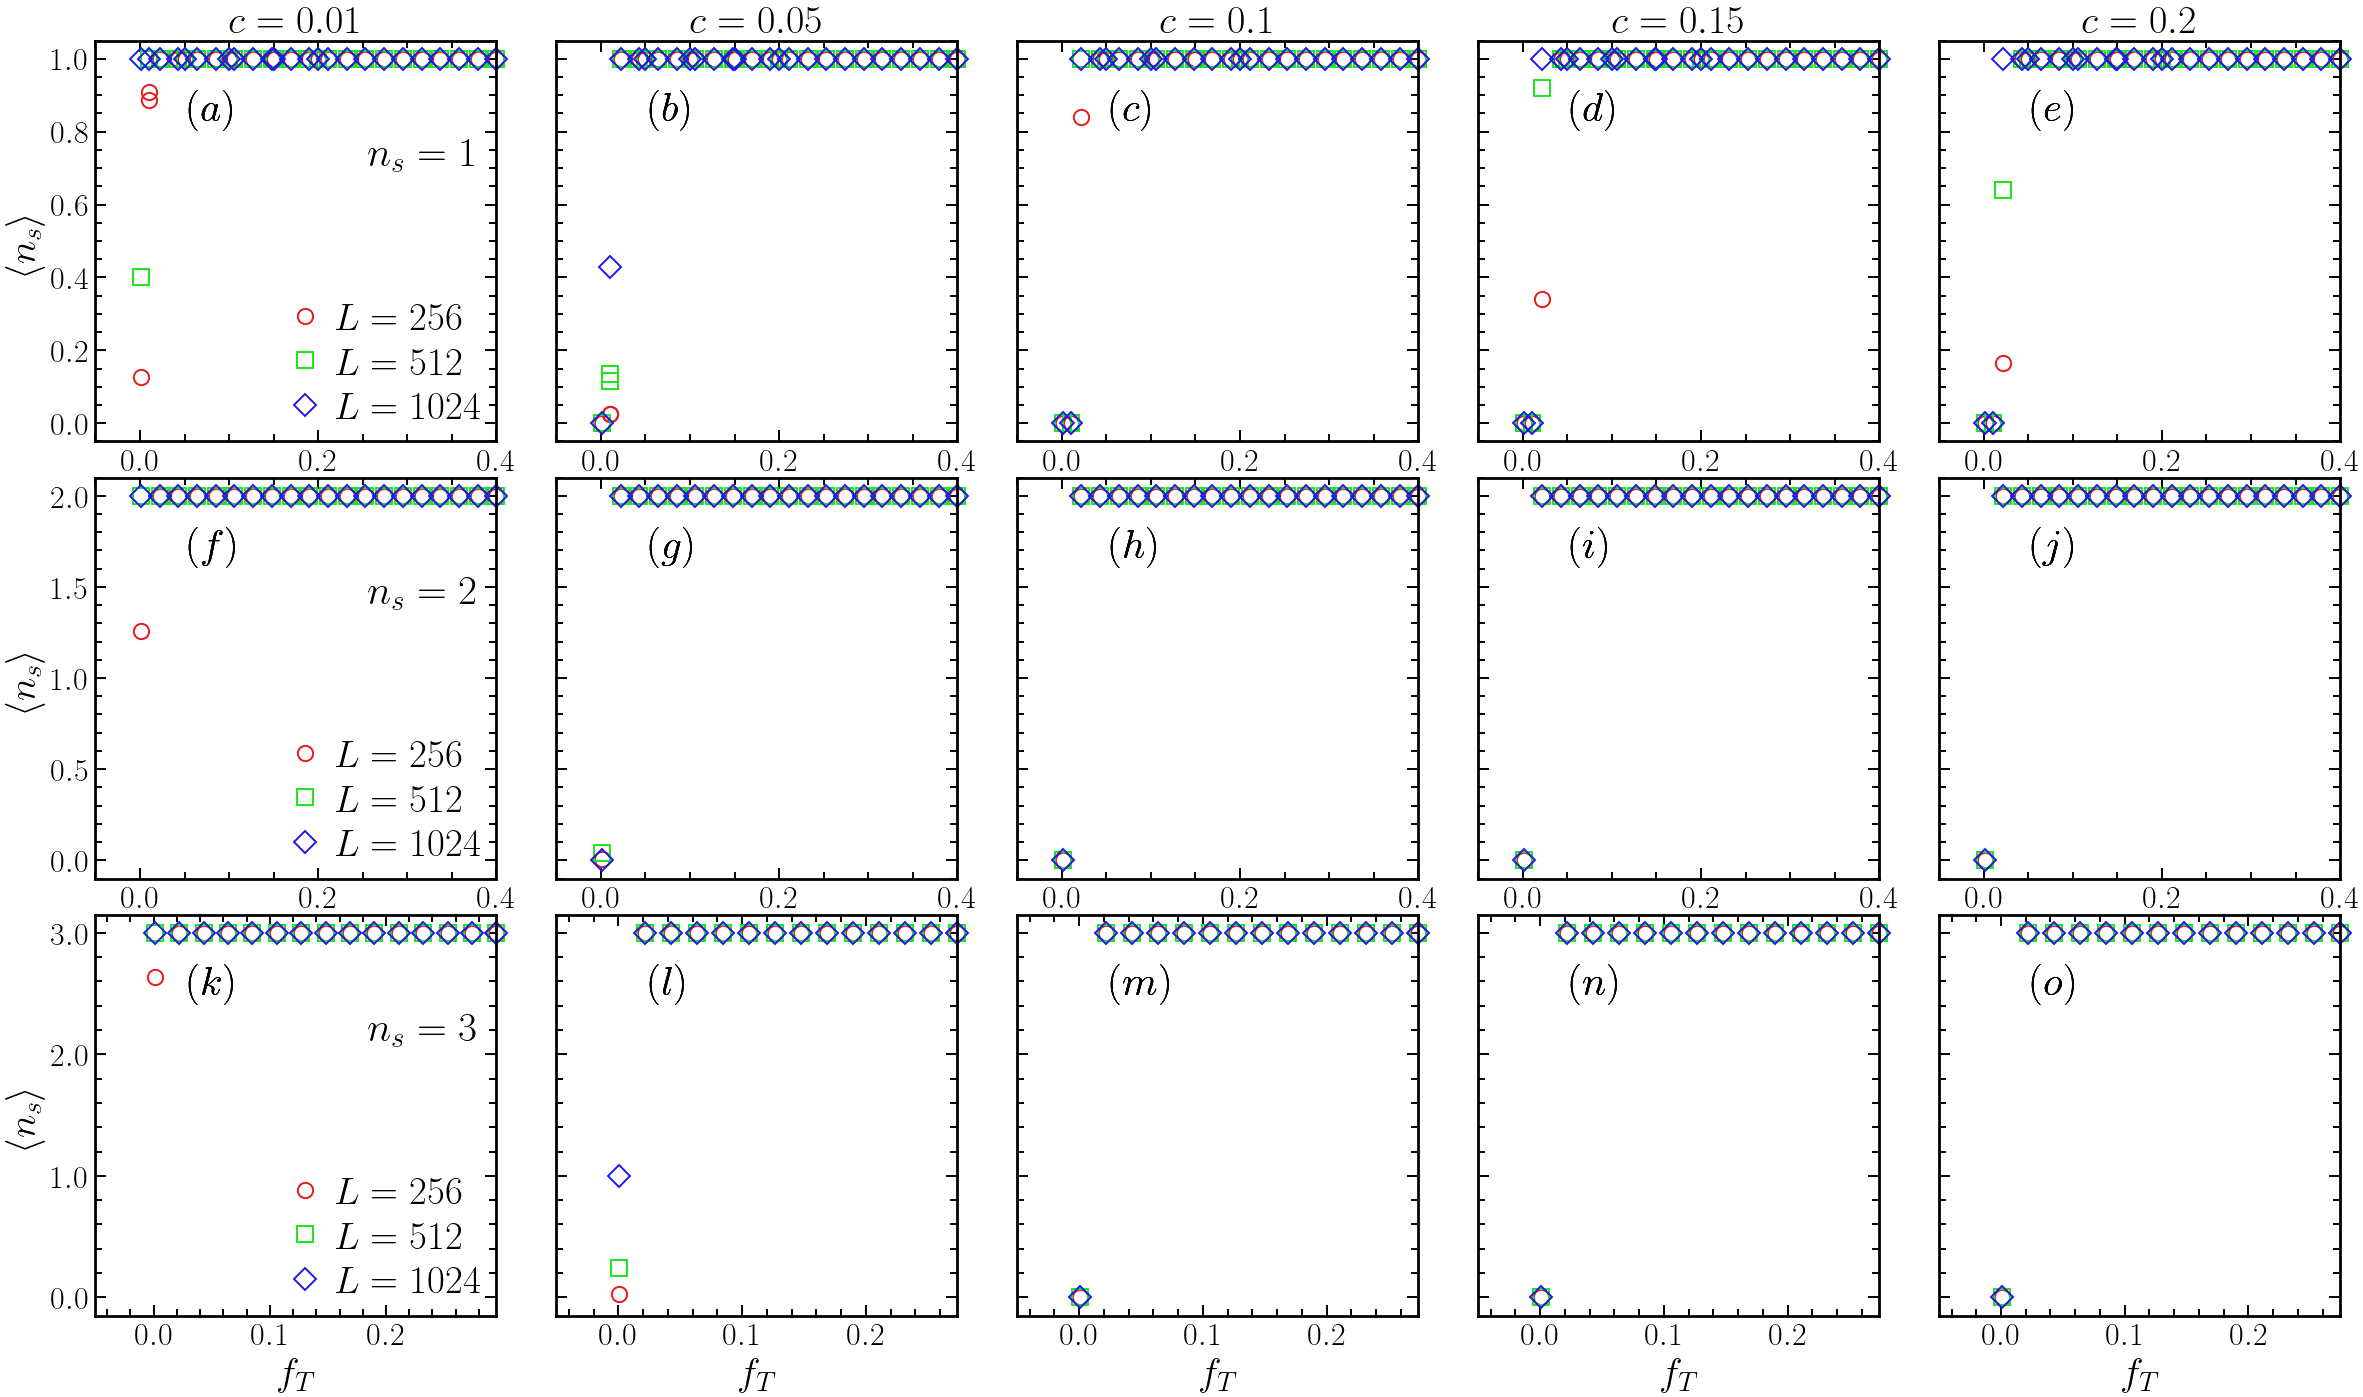

In [6]:
# PLOT <N_S>
fig, axes, parms, ft_bounds = plot_nc_dynamic_grid(
    df_dynamic=df_dynamic,
    df_series=df_series,
    L_lst=[256, 512, 1024],
    ns_lst=[1, 2, 3],
    c_lst=[0.01, 0.05, 0.1, 0.15, 0.2],
    base=5,
    dim=3,
    order=0,
    p0=0.6,
    wspace=0.01,
    hspace=0.09,
    legend_loc='lower right',
    tick_fs=23,
    label_fs=29,
    title_fs=29,
    p_cut=0.70,
    ms=11,
    mew=1.4,
    print_bounds=True,
    fs_legend=28,
    ns_text_x=0.68,
    ns_text_y=0.76,
    ns_text_fs=30,
    panel_label_x=0.23,
    panel_label_y=0.88,
    panel_label_fs=30,
    savepath=results_folder + '/n_s_3D.pdf',
)

plt.show()

ns=1 | c=0.01 | rho=1.00000 | ft_min=0.022000 | ft_max=0.400000
ns=1 | c=0.02 | rho=1.00000 | ft_min=0.022000 | ft_max=0.400000
ns=1 | c=0.03 | rho=1.00000 | ft_min=0.022000 | ft_max=0.400000
ns=1 | c=0.04 | rho=1.00000 | ft_min=0.043000 | ft_max=0.400000
ns=1 | c=0.05 | rho=1.00000 | ft_min=0.022000 | ft_max=0.400000
ns=2 | c=0.01 | rho=0.50000 | ft_min=0.022000 | ft_max=0.400000
ns=2 | c=0.02 | rho=0.50000 | ft_min=0.022000 | ft_max=0.400000
ns=2 | c=0.03 | rho=0.50000 | ft_min=0.022000 | ft_max=0.400000
ns=2 | c=0.04 | rho=0.50000 | ft_min=0.022000 | ft_max=0.400000
ns=2 | c=0.05 | rho=0.50000 | ft_min=0.022000 | ft_max=0.400000
ns=3 | c=0.01 | rho=0.33333 | ft_min=0.022000 | ft_max=0.295000
ns=3 | c=0.02 | rho=0.33333 | ft_min=0.022000 | ft_max=0.295000
ns=3 | c=0.03 | rho=0.33333 | ft_min=0.022000 | ft_max=0.295000
ns=3 | c=0.04 | rho=0.33333 | ft_min=0.022000 | ft_max=0.274000
ns=3 | c=0.05 | rho=0.33333 | ft_min=0.022000 | ft_max=0.274000


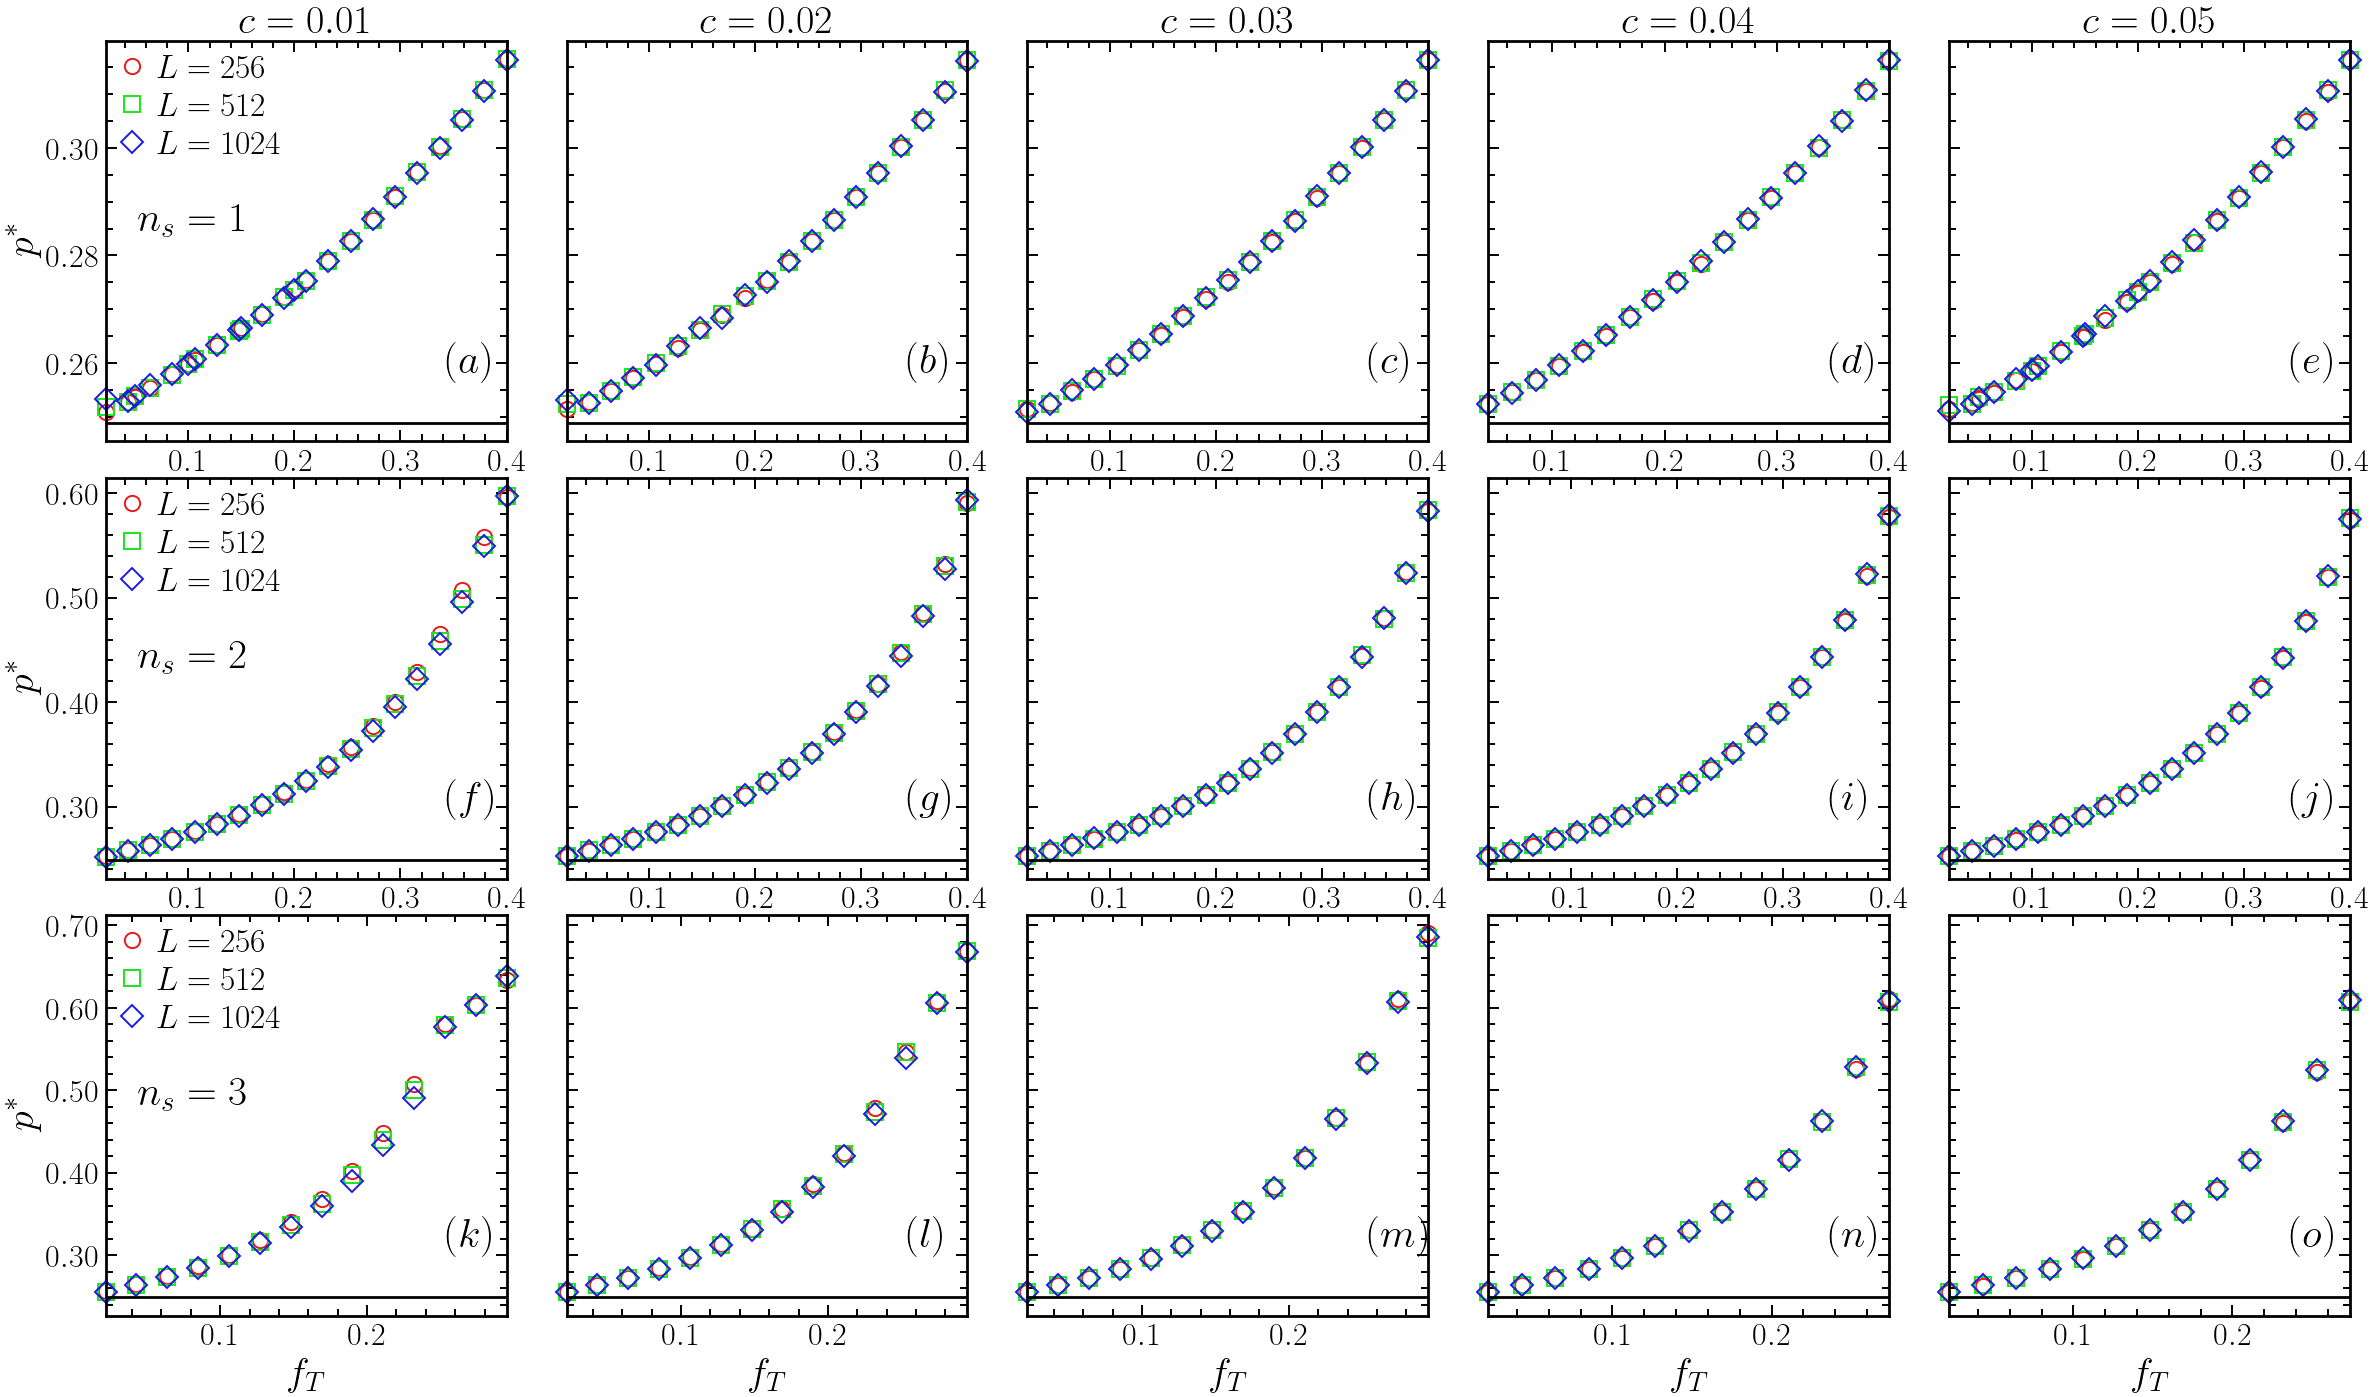

In [9]:
# PLOT <N_S>
fig, axes, parms, ft_bounds = plot_pmean_series_grid(
    df_dynamic=df_dynamic,
    df_series=df_series,
    L_lst=[256, 512, 1024],
    ns_lst=[1, 2, 3],
#    c_lst=[0.01, 0.05, 0.1, 0.15, 0.2],
    c_lst=[0.01, 0.02, 0.03, 0.04, 0.05],
    base=5,
    dim=3,
    p_cut=0.70,
    order=0,
    p0=0.6,
    wspace=0.01,
    hspace=0.09,
    legend_loc='upper left',
    tick_fs=23,
    label_fs=29,
    title_fs=29,
    ms=11,
    mew=1.4,
    print_bounds=True,
    fs_legend=24,
    ns_text_x=0.08,
    ns_text_y=0.60,
    ns_text_fs=30,
    panel_label_x=0.85,
    panel_label_y=0.25,
    panel_label_fs=30,
    pc=0.24881182,
    savepath=results_folder + '/p_mean_3D.pdf',
)

plt.show()

In [8]:
# Save minimum ft and max
df = pd.DataFrame(data=parms)
df.to_csv('../SOP_data/ft_values_3D.dat',index=False)